In [ ]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print(df.head())
print(df.shape)

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

This cell imports the pandas library and loads the HR Employee Attrition dataset from a CSV file into a DataFrame called `df`. It then prints the first 5 rows and the shape (number of rows and columns) of the DataFrame to give an initial overview of the data.

In [ ]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

This cell checks for missing values in each column of the DataFrame. The `isnull().sum()` method counts the number of null (missing) entries per column. In this dataset, it appears there are no missing values.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

This cell provides a concise summary of the DataFrame, including the data types of each column, the number of non-null values, and memory usage. This helps in understanding the structure and content of the dataset.

In [ ]:
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})

This cell converts the 'Attrition' column from categorical ('Yes', 'No') to numerical (1, 0). This is a necessary step for machine learning models that require numerical input.

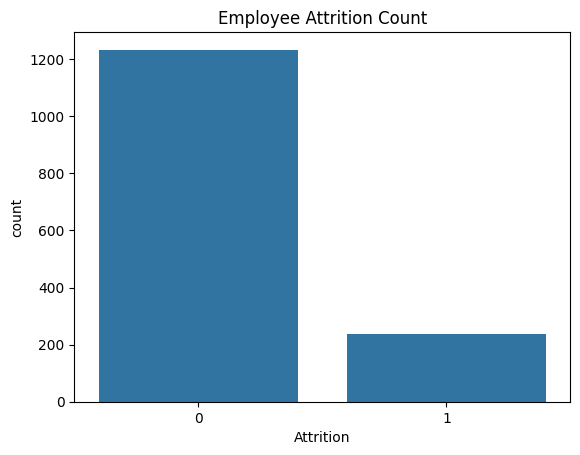

In [ ]:
sns.countplot(x='Attrition', data=df)
plt.title("Employee Attrition Count")
plt.show()

This cell generates a count plot using `seaborn` to visualize the distribution of 'Attrition' (Yes/No). It shows the number of employees who have left versus those who have not, providing a baseline understanding of the target variable.

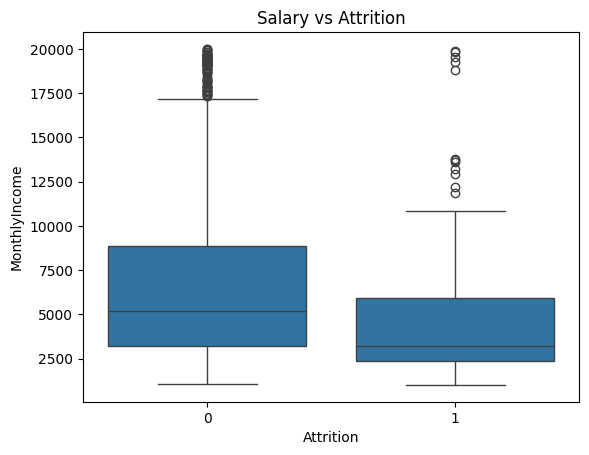

In [ ]:
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Salary vs Attrition")
plt.show()

This cell creates a box plot to examine the relationship between 'MonthlyIncome' and 'Attrition'. It helps to visualize if there's a significant difference in monthly income between employees who attrite and those who don't.

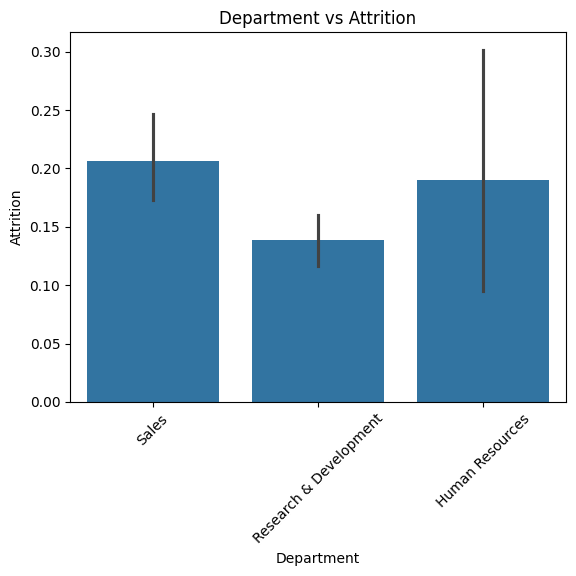

In [ ]:
sns.barplot(x='Department', y='Attrition', data=df)
plt.title("Department vs Attrition")
plt.xticks(rotation=45)
plt.show()

This cell uses a bar plot to show the attrition rate across different 'Department' categories. It helps identify which departments might have higher or lower attrition compared to others.

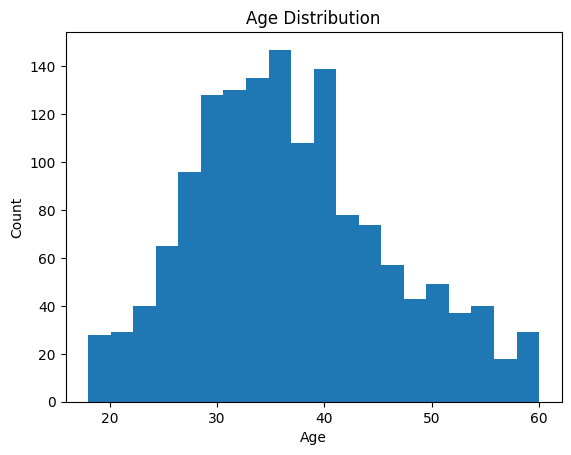

In [ ]:
plt.hist(df['Age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

This cell generates a histogram of the 'Age' column, illustrating the distribution of employee ages within the dataset. This helps understand the age demographic of the workforce.

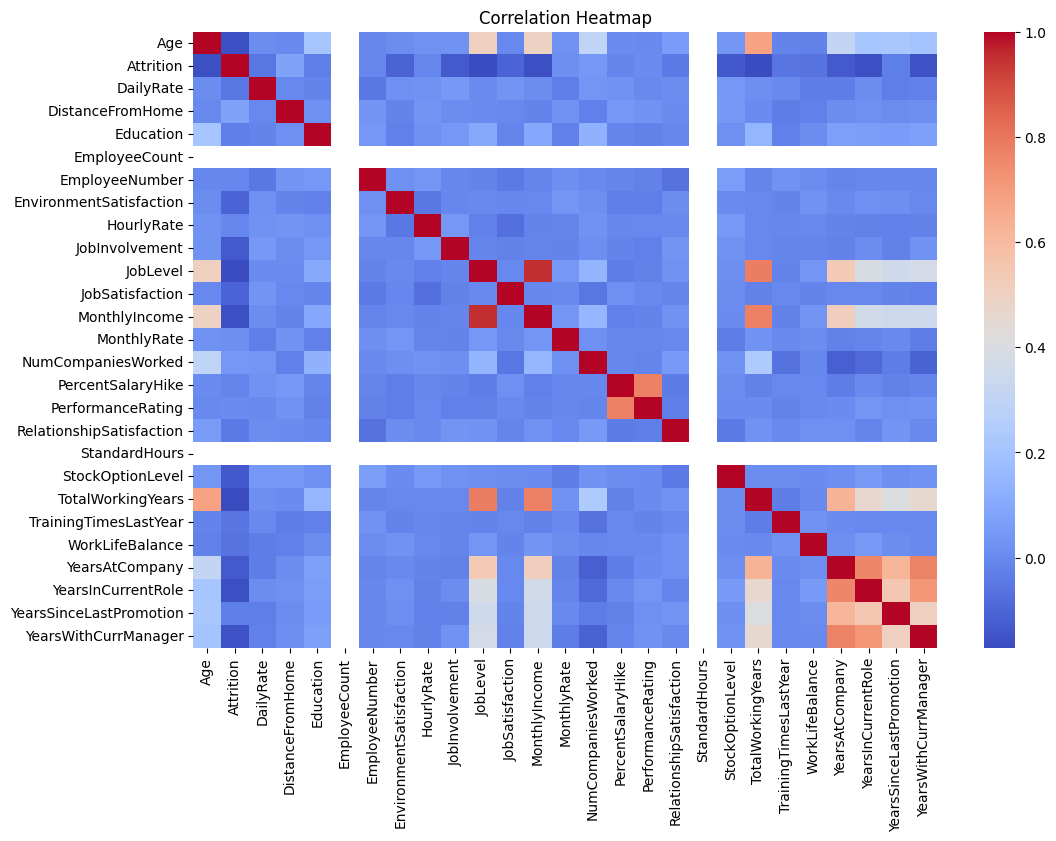

In [ ]:
import numpy as np

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

This cell calculates and visualizes the correlation matrix for all numerical features in the DataFrame using a heatmap. A heatmap helps identify highly correlated variables, which can be useful for feature selection and understanding relationships.

In [ ]:
df = pd.get_dummies(df, drop_first=True)

This cell performs one-hot encoding on the categorical columns in the DataFrame using `pd.get_dummies`. This converts categorical text data into a numerical format suitable for machine learning algorithms. `drop_first=True` is used to avoid multicollinearity.

In [ ]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

This cell separates the features (independent variables) from the target variable. `X` contains all columns except 'Attrition', and `y` contains only the 'Attrition' column.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

This cell splits the dataset into training and testing sets using `train_test_split` from `sklearn.model_selection`. The training set is used to train the model, and the testing set is used to evaluate its performance on unseen data. Here, 20% of the data is allocated for testing.

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=5000)

This cell initializes and trains a Logistic Regression model from `sklearn.linear_model`. Logistic Regression is a common algorithm for binary classification tasks like attrition prediction. `max_iter` is set to 5000 to help with convergence.

In [ ]:
predictions = model.predict(X_test)

This cell uses the trained Logistic Regression model to make predictions on the test set (`X_test`). The `predict()` method outputs the predicted attrition (0 or 1) for each employee in the test set.

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8979591836734694


This cell calculates the accuracy of the model's predictions. `accuracy_score` compares the true attrition values (`y_test`) with the predicted attrition values and returns the proportion of correctly classified instances.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.92      0.97      0.94       255
           1       0.70      0.41      0.52        39

    accuracy                           0.90       294
   macro avg       0.81      0.69      0.73       294
weighted avg       0.89      0.90      0.89       294



This cell generates a detailed classification report, which includes precision, recall, F1-score, and support for each class (0 and 1). This report provides a more comprehensive evaluation of the model's performance beyond just accuracy.

In [ ]:
df.to_csv("employee_attrition_cleaned.csv", index=False)

This cell saves the processed DataFrame, including the encoded categorical variables, into a new CSV file named `employee_attrition_cleaned.csv`. The `index=False` argument prevents writing the DataFrame index to the CSV.

In [ ]:
from google.colab import files
files.download("employee_attrition_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

This cell uses the `files.download` utility from `google.colab` to download the `employee_attrition_cleaned.csv` file to your local machine, allowing you to access the cleaned dataset outside of the Colab environment.